# Get started
## Read dataset, get bbox, visualize image

In [1]:
import json
import matplotlib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import csv
import random

In [2]:
import cv2
import torch
from math import floor, ceil
from torch.utils.data import Dataset, DataLoader, random_split

In [3]:
def draw_rectangle(ax, top_left_x, top_left_y, width, height, color='red'):
    top_left = (top_left_x, top_left_y)
    bottom_right = (top_left_x + width, top_left_y + height)

    # Plotting each edge of the rectangle on the specified axes
    ax.plot([top_left[0], top_left[0]], [top_left[1], bottom_right[1]], '-', color=color)           # Left edge
    ax.plot([bottom_right[0], bottom_right[0]], [top_left[1], bottom_right[1]], '-', color=color)   # Right edge
    ax.plot([top_left[0], bottom_right[0]], [top_left[1], top_left[1]], '-', color=color)           # Top edge
    ax.plot([top_left[0], bottom_right[0]], [bottom_right[1], bottom_right[1]], '-', color=color)   # Bottom edge

In [4]:
class ObjectDetectionDataset(Dataset):
    def __init__(self, dataset_dir):
        self.dataset_dir = dataset_dir
        with open(f'{self.dataset_dir}/annotations.json', 'r') as file:
            self.data = json.load(file)
            self.indicies = list(self.data.keys())

    def __len__(self):
        return len(self.data.keys())

    def __getitem__(self, idx):
        idx = self.indicies[idx]
        annotes = [annt + annt[:1] for annt in self.data[f"{idx}"]]
        img = Image.open(f'{self.dataset_dir}/frames/frame_{idx}.jpg')
        boxes = [self.get_bbox(annt) for annt in annotes]

        return img, boxes

    def get_bbox(self, polygon):
        x_min = min([point[0] for point in polygon])
        x_max = max([point[0] for point in polygon])
        y_min = min([point[1] for point in polygon])
        y_max = max([point[1] for point in polygon])

        cx = (x_min + x_max) // 2
        cy = (y_min + y_max) // 2
        width = floor(x_max - x_min)
        height = floor(y_max - y_min)

        return cx, cy, width, height

In [5]:
data_folder = '/home/njx4489/repod/tank_boy/dataset'
train_folder = os.path.join(data_folder, "train")
dataset = ObjectDetectionDataset(train_folder)

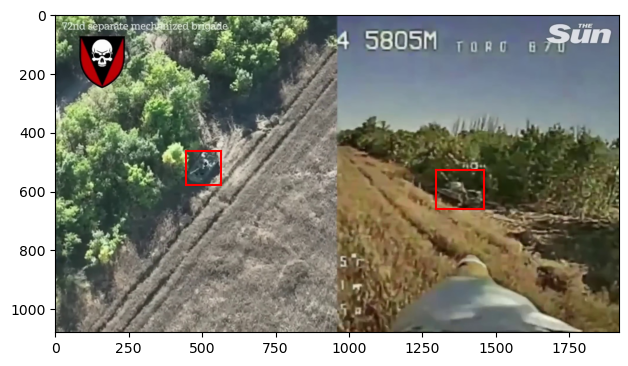

In [6]:
img, boxes = dataset[np.random.randint(len(dataset))]

plt.figure(figsize=(16, 16))
plt.subplot(121)
plt.imshow(img)

for box in boxes:
    cx, cy, width, height = box
    draw_rectangle(plt.gca(), cx - width // 2, cy - height // 2, width, height)

plt.show()

In [7]:
#This Generates a random submission table in the correct format
#The number of images is correct, but the values in cells do not necessarily have to fall within
#the generated range. 
num_images = 433  # from 0 to 432

output_file = "random_submission.csv"

with open(output_file, mode='w', newline='') as file:
    writer = csv.writer(file, delimiter=",")

    # Write the header
    writer.writerow(["image_id", "x_min", "y_min", "x_max", "y_max", "class_id"])

    # Write the data rows
    for image_id in range(num_images):
        num = random.randint(1, 2) # number of prediction for a single image
        x_min = ';'.join([str(random.randint(1, 1000)) for _ in range(num)])
        y_min = ';'.join([str(random.randint(1, 1000)) for _ in range(num)])
        x_max = ';'.join([str(random.randint(1, 1000)) for _ in range(num)])
        y_max = ';'.join([str(random.randint(1, 1000)) for _ in range(num)])
        class_id = 0
        writer.writerow([image_id, x_min, y_min, x_max, y_max, class_id])


In [8]:
!head submission.csv

image_id,x_min,y_min,x_max,y_max,class_id
0,276 344,89 115,345 384,128 144,0
1,283 340,89 96,340 389,118 131,0
2,262,284,390,399,0
3,233,27,481,480,0
4,293,107,491,220,0
5,143 451,204 248,185 489,258 278,0
6,315,72,404,117,0
7,309,140,498,254,0
8,235,300,343,367,0
